## 1. Environment Setup for Interactive Auditing
We install `streamlit` for building the interactive fairness dashboard and `localtunnel` to expose the local port for web access.

In [16]:
!pip -q install streamlit
!npm -q install localtunnel

⠙⠹⠸⠼⠴⠦⠧
up to date, audited 23 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠇

## 2. Cohort Diagnostics and Demographic Distributions
Before generating counterfactuals, we inspect the preprocessed `mimic_features.parquet` dataset. This custom HTML dashboard verifies the data schema, confirms the presence of required identifiers, and visualizes the baseline demographic distributions (Age, Sex, Race, and Insurance) to ensure adequate representation for fairness auditing.

In [1]:
import os
import glob
import pandas as pd
from IPython.display import display, HTML

# Paths to inspect
dataset_dir = "/kaggle/input/datasets/luwammajor/clinical-pipeline-preprocessed"
parquet_path = os.path.join(dataset_dir, "mimic_features.parquet")

# 1. Directory inspection
all_files = glob.glob(f"{dataset_dir}/*")
files_list = "".join([f"<li><code>{os.path.basename(f)}</code> ({os.path.getsize(f) / (1024 * 1024):.2f} MB)</li>" for f in all_files])

# 2. Load dataset
df = pd.read_parquet(parquet_path)

# 3. Columns and Types
schema_df = pd.DataFrame({"Column": df.columns, "Dtype": df.dtypes.astype(str)}).head(12)
schema_html = schema_df.to_html(index=False, classes="table table-sm table-striped")

# 4. Demographic distributions side by side
demo_cols = [c for c in df.columns if any(k in c.lower() for k in ["race", "sex", "gender", "insur", "age", "ethnicity"])]
dist_tables_html = ""
for col in demo_cols[:4]:
    vc = df[col].value_counts(dropna=False).head(5).reset_index()
    vc.columns = [col, "Count"]
    dist_tables_html += f"""
    <div style="flex: 1; min-width: 180px; margin: 4px; padding: 8px; border: 1px solid rgba(128, 128, 128, 0.3); border-radius: 4px; background-color: transparent;">
        <h6 style="margin: 0 0 6px 0; font-weight: 600; color: inherit;">{col}</h6>
        {vc.to_html(index=False, classes="table table-sm")}
    </div>
    """

# 5. Identifier / text columns check
id_text_cols = [c for c in df.columns if any(k in c.lower() for k in ["id", "text", "note", "section"])]
id_text_html = "".join([f"<span style='background-color: rgba(26, 115, 232, 0.15); color: #4285f4; padding: 2px 6px; margin: 2px; border-radius: 3px; display: inline-block;'>{c}</span>" for c in id_text_cols])

#  diagnostic dashboard
dashboard_html = f"""
<div style="font-family: system-ui, -apple-system, sans-serif; font-size: 13px; line-height: 1.4; color: inherit; background-color: transparent;">
    <div style="display: flex; flex-wrap: wrap; gap: 12px; margin-bottom: 12px;">
        
        <!-- Left Panel: Directory & Metadata -->
        <div style="flex: 1; min-width: 280px; padding: 12px; border: 1px solid rgba(128, 128, 128, 0.3); border-radius: 6px; background-color: transparent;">
            <h5 style="margin-top: 0; color: inherit; border-bottom: 2px solid rgba(59, 130, 246, 0.6); padding-bottom: 4px;">1. Directory & File Info</h5>
            <p style="margin: 4px 0;"><strong>Dataset Shape:</strong> {df.shape[0]:,} rows &times; {df.shape[1]} cols</p>
            <p style="margin: 4px 0;"><strong>Files in Directory:</strong></p>
            <ul style="padding-left: 18px; margin: 4px 0;">{files_list}</ul>
            <p style="margin: 8px 0 4px 0;"><strong>ID / Text Columns Found:</strong></p>
            <div>{id_text_html}</div>
        </div>

        <!-- Right Panel: First 12 Schema Fields -->
        <div style="flex: 1.2; min-width: 320px; padding: 12px; border: 1px solid rgba(128, 128, 128, 0.3); border-radius: 6px; background-color: transparent;">
            <h5 style="margin-top: 0; color: inherit; border-bottom: 2px solid rgba(16, 185, 129, 0.6); padding-bottom: 4px;">2. Schema Overview (Preview)</h5>
            <div style="max-height: 200px; overflow-y: auto;">
                {schema_html}
            </div>
        </div>
    </div>

    <!-- Bottom Panel: Demographic Distributions Side-by-Side -->
    <div style="padding: 12px; border: 1px solid rgba(128, 128, 128, 0.3); border-radius: 6px; background-color: transparent; margin-bottom: 12px;">
        <h5 style="margin-top: 0; color: inherit; border-bottom: 2px solid rgba(139, 92, 246, 0.6); padding-bottom: 4px;">3. Demographic Distributions</h5>
        <div style="display: flex; flex-wrap: wrap; gap: 8px;">
            {dist_tables_html}
        </div>
    </div>
</div>
"""

display(HTML(dashboard_html))

# 6. Sample Transposed Row
print("=== 4. SAMPLE RECORD (FIRST ROW TRANSPOSED) ===")
display(df.head(1).T)

Column,Dtype
subject_id,int64
hadm_id,int64
admittime,datetime64[ns]
dischtime,datetime64[ns]
age,int64
sex,object
race_clean,object
insurance_clean,object
admission_type,object
los_days,float64


=== 4. SAMPLE RECORD (FIRST ROW TRANSPOSED) ===


,0
subject_id,10000032
hadm_id,22595853
admittime,2180-05-06 22:23:00
dischtime,2180-05-07 17:15:00
age,52
sex,Female
race_clean,White
insurance_clean,Medicaid
admission_type,URGENT
los_days,0.786111


## 3. Data Integration and Perturbation Maps
We load the raw clinical discharge summaries and join them with the demographic features (Race and Sex) using `hadm_id`. We also define the counterfactual transformation dictionaries (`RACE_MAP` and `SEX_MAP`), which specify how factual demographic markers (e.g., "african american", "male") will be swapped with their counterfactual equivalents (e.g., "white", "female").

In [2]:
import os
import re
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util

# File paths
features_path = "/kaggle/input/datasets/luwammajor/clinical-pipeline-preprocessed/mimic_features.parquet"
notes_path = "/kaggle/input/datasets/luwammajor/mimic-iv-notes/discharge.csv"

# Load tabular demographic features
print("Loading demographic features...")
features_df = pd.read_parquet(features_path)

# Load text notes (only reading required columns to conserve RAM)
print("Loading clinical discharge summaries...")
notes_df = pd.read_csv(notes_path, usecols=["hadm_id", "text"])

# Ensure ID types match and merge
features_df["hadm_id"] = features_df["hadm_id"].astype(int)
notes_df["hadm_id"] = notes_df["hadm_id"].astype(int)

print("Merging tabular features with clinical notes...")
merged_df = pd.merge(
    notes_df,
    features_df[["hadm_id", "race_clean", "sex", "race_x_sex"]],
    on="hadm_id",
    how="inner"
)
print(f"Merge successful: {len(merged_df):,} matched clinical encounters.")

# Demographic perturbation maps
RACE_MAP = {
    "african american": "white",
    "black": "white",
    "caucasian": "black",
    "white": "black",
    "hispanic": "white",
    "latino": "white",
    "asian": "white"
}

SEX_MAP = {
    "male": "female",
    "female": "male",
    "man": "woman",
    "woman": "man"
}

Loading demographic features...
Loading clinical discharge summaries...
Merging tabular features with clinical notes...
Merge successful: 293,760 matched clinical encounters.


## 4. Counterfactual Generation Engine
This function applies regex-bound string substitutions to the clinical text[. By searching for exact word boundaries (`\b`), it safely swaps demographic keywords without unintentionally altering sub-strings inside other medical terms.

In [4]:
def perturb_demographics(text: str, target_axis: str) -> str:
    """
    Applies regex-bound string substitution to swap demographic markers.
    """
    if pd.isna(text):
        return str(text)
    
    perturbed = str(text).lower()
    mapping = RACE_MAP if target_axis == "race" else SEX_MAP
    
    for factual, counterfactual in mapping.items():
        pattern = re.compile(rf"\b{re.escape(factual)}\b")
        perturbed = pattern.sub(counterfactual, perturbed)
        
    return perturbed

## 5. Full-Cohort Counterfactual Transformation
We apply the perturbation engine across the entire cohort, generating two new parallel text columns: `text_cf_race` and `text_cf_sex`. These represent alternative realities where the patient's demographics differ, but their clinical presentation remains identical.

In [5]:
# Apply regex to the ENTIRE dataset
print("Generating counterfactual notes for the entire dataset")
merged_df["text_cf_race"] = merged_df["text"].apply(lambda x: perturb_demographics(x, "race"))
merged_df["text_cf_sex"] = merged_df["text"].apply(lambda x: perturb_demographics(x, "sex"))
print(f"Successfully generated counterfactuals for {len(merged_df):,} records.")

Generating counterfactual notes for the entire dataset
Successfully generated counterfactuals for 293,760 records.


## 6. Semantic Preservation Check
To ensure the perturbation step did not accidentally destroy the clinical meaning of the notes, we validate a 2,000-record sample using Sentence-BERT (`all-MiniLM-L6-v2`) We compute the cosine similarity between the factual and counterfactual embeddings. A high similarity score proves the text's semantic integrity remains intact.

In [6]:
# STATISTICAL VALIDATION: Run SBERT only on a 2,000-record subset
print("\nSampling 2,000 records for SBERT validation...")
validation_sample = merged_df.sample(n=2000, random_state=42).copy()

print("Loading SBERT model: all-MiniLM-L6-v2...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Computing factual embeddings for the sample...")
factual_emb = model.encode(validation_sample["text"].tolist(), convert_to_tensor=True, show_progress_bar=True)

for cf_col in ["text_cf_race", "text_cf_sex"]:
    print(f"Validating semantic preservation for {cf_col}...")
    cf_emb = model.encode(validation_sample[cf_col].tolist(), convert_to_tensor=True, show_progress_bar=True)
    scores = util.cos_sim(factual_emb, cf_emb).diagonal()
    validation_sample[f"similarity_{cf_col}"] = scores.cpu().numpy()

print("\n=== Semantic Similarity Validation Summary (n=2000) ===")
display(validation_sample[["similarity_text_cf_race", "similarity_text_cf_sex"]].describe())


Sampling 2,000 records for SBERT validation...
Loading SBERT model: all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Validating semantic preservation for text_cf_sex...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]


=== Semantic Similarity Validation Summary (n=2000) ===


,similarity_text_cf_race,similarity_text_cf_sex
count,2000.000000,2000.000000
mean,0.999921,0.999701
std,0.000781,0.000873
min,0.982298,0.988582
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000001,1.000001


## 7. Semantic Similarity Distribution
This Kernel Density Estimation (KDE) plot visualizes the SBERT cosine similarity scores for both race and sex counterfactuals. We plot this against a strict validity threshold (0.95) to visually confirm that the perturbations are semantically safe.

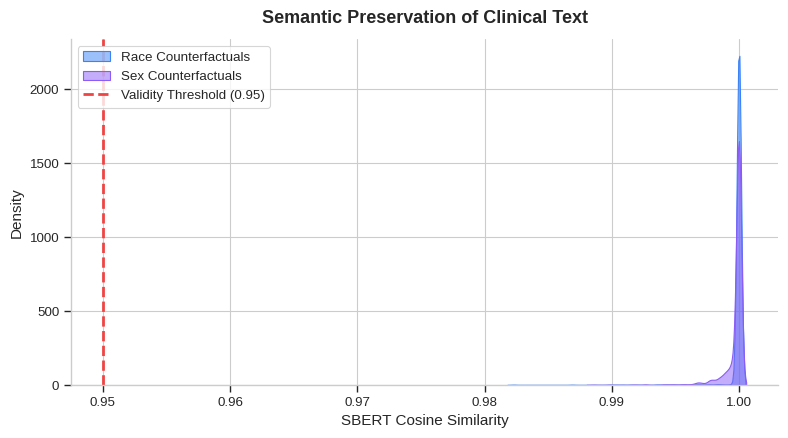

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.1)

def plot_semantic_preservation(df):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    # Plot KDEs for the distributions
    sns.kdeplot(data=df, x="similarity_text_cf_race", fill=True, label="Race Counterfactuals", color="#3b82f6", alpha=0.5, ax=ax)
    sns.kdeplot(data=df, x="similarity_text_cf_sex", fill=True, label="Sex Counterfactuals", color="#8b5cf6", alpha=0.5, ax=ax)
    
    # Add the validation threshold line
    ax.axvline(x=0.95, color='#ef4444', linestyle='--', linewidth=2, label='Validity Threshold (0.95)')
    
    # Formatting
    ax.set_title("Semantic Preservation of Clinical Text", fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("SBERT Cosine Similarity", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(loc='upper left', frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_semantic_preservation(validation_sample)

## 8. Bias Migration Divergence Function
This function visualizes the core metric of our audit: $\Delta f(x)$. It plots the distribution of the difference between factual and counterfactual risk scores. In a perfectly fair system, this distribution will center exactly on zero.

In [ ]:
def plot_bias_divergence(df, metric_col="comorbidity_burden_score"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    # Calculate divergence: Factual Score - Counterfactual Score
    # (Assuming you will merge the factual and CF LLM outputs into these columns)
    divergence = df[f"factual_{metric_col}"] - df[f"cf_{metric_col}"]
    
    # Plot the histogram of differences
    sns.histplot(divergence, bins=20, kde=True, color="#10b981", ax=ax)
    
    # Add a zero line representing perfect fairness
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, label='Zero Divergence (Perfectly Fair)')
    
    # Formatting
    ax.set_title(f"Bias Migration Divergence: {metric_col}", fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("$\Delta f(x)$ (Factual - Counterfactual)", fontsize=11)
    ax.set_ylabel("Patient Encounter Count", fontsize=11)
    ax.legend(loc='upper right', frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# for later:
# plot_bias_divergence(final_merged_results_df, metric_col="comorbidity_burden_score")

## 9. Interactive Fairness Explorer Deployment
We write the `app.py` script to generate a dynamic Streamlit dashboard. This tool allows others to toggle between demographic axes, adjust the semantic similarity threshold, and instantly visualize how bias divergence shifts across valid subgroups.

In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(page_title="Bias Audit Dashboard", layout="wide")

st.title("Counterfactual Fairness & Semantic Integrity Explorer")
st.markdown("Audit dashboard for clinical extraction pipelines mapping factual versus counterfactual risk divergence.")

# Data function
@st.cache_data
def load_mock_data(n_samples=500):
    np.random.seed(42)
    # Generate mock factual risk scores
    factual_risk = np.random.normal(loc=10, scale=3, size=n_samples)
    
    # Generate counterfactual scores with slight synthetic bias
    cf_risk_race = factual_risk + np.random.normal(loc=0.5, scale=1.5, size=n_samples)
    cf_risk_sex = factual_risk + np.random.normal(loc=-0.2, scale=1.0, size=n_samples)
    
    # Generate mock SBERT semantic similarities
    sim_race = np.clip(np.random.normal(loc=0.97, scale=0.03, size=n_samples), 0, 1)
    sim_sex = np.clip(np.random.normal(loc=0.98, scale=0.02, size=n_samples), 0, 1)
    
    return pd.DataFrame({
        "hadm_id": range(100000, 100000 + n_samples),
        "factual_risk": factual_risk,
        "cf_risk_race": cf_risk_race,
        "cf_risk_sex": cf_risk_sex,
        "similarity_race": sim_race,
        "similarity_sex": sim_sex
    })

df = load_mock_data()

# Configure sidebar controls for interactive filtering
st.sidebar.header("Audit Controls")
axis_choice = st.sidebar.radio("Demographic Axis", ["Race", "Sex"])
threshold = st.sidebar.slider("Semantic Similarity Threshold", min_value=0.80, max_value=1.00, value=0.95, step=0.01)

# Map user selections to dataframe columns
if axis_choice == "Race":
    cf_col = "cf_risk_race"
    sim_col = "similarity_race"
else:
    cf_col = "cf_risk_sex"
    sim_col = "similarity_sex"

# Apply semantic validity gate and calculate bias divergence
df["Valid"] = df[sim_col] >= threshold
df["Divergence"] = df["factual_risk"] - df[cf_col]
valid_df = df[df["Valid"]]

# Render top metric cards
col1, col2, col3 = st.columns(3)
col1.metric("Total Encounters", len(df))
col2.metric("Valid (Above Threshold)", len(valid_df), f"{(len(valid_df)/len(df))*100:.1f}%")

if not valid_df.empty:
    col3.metric("Mean Bias Divergence", f"{valid_df['Divergence'].mean():.2f}")
else:
    col3.metric("Mean Bias Divergence", "N/A")

st.divider()

# side-by-side plots for Risk Scatter and Similarity Distribution
row1_col1, row1_col2 = st.columns(2)

with row1_col1:
    st.subheader(f"Factual vs Counterfactual Risk ({axis_choice})")
    
    fig_scatter = px.scatter(
        df, 
        x="factual_risk", 
        y=cf_col, 
        color="Valid",
        color_discrete_map={True: "#10b981", False: "#d1d5db"},
        opacity=0.7,
        labels={"factual_risk": "Factual Risk Score", cf_col: "Counterfactual Risk Score"}
    )
    
    # Add y=x reference line representing perfect fairness
    fig_scatter.add_shape(type="line", x0=0, y0=0, x1=20, y1=20, line=dict(color="black", dash="dash"))
    st.plotly_chart(fig_scatter, use_container_width=True)

with row1_col2:
    st.subheader("Semantic Similarity Distribution")
    
    fig_sim = px.histogram(
        df, 
        x=sim_col, 
        nbins=40,
        color_discrete_sequence=["#3b82f6"],
        labels={sim_col: "Cosine Similarity"}
    )
    
    # Add vertical line for the dynamic threshold
    fig_sim.add_vline(x=threshold, line_width=2, line_dash="dash", line_color="red")
    st.plotly_chart(fig_sim, use_container_width=True)

st.divider()

# Render the final divergence histogram for the valid subset
st.subheader("Bias Divergence Distribution (Valid Subset Only)")
st.markdown(r"Measures $\Delta f(x) = f(x) - f(x^\prime)$. A perfectly fair system centers exactly on zero.")

if not valid_df.empty:
    fig_div = px.histogram(
        valid_df,
        x="Divergence",
        nbins=30,
        color_discrete_sequence=["#8b5cf6"],
        labels={"Divergence": "Difference (Factual - Counterfactual)"}
    )
    fig_div.add_vline(x=0, line_width=2, line_dash="solid", line_color="black")
    st.plotly_chart(fig_div, use_container_width=True)
else:
    st.warning("No data points passed the current semantic similarity threshold.")

Writing app.py


## 10. Run Application
This cell executes the Streamlit app in the background and tunnels it to a public URL so we can interact with the dashboard directly from our browser.

In [ ]:
!streamlit run app.py &>./logs.txt & npx localtunnel --port 8501